# Explore here

In [26]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [29]:
df.shape

(1338, 7)

In [30]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

EXPLORACIÓN Y LIMPIEZA DE DATOS

In [31]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [32]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [33]:
print("Filas antes de eliminar duplicados:", df.shape[0])
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas antes de eliminar duplicados: 1338
Filas después de eliminar duplicados: 1337


In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


ANÁLISIS DE VARIABLES UNIVARIANTE

Distribución sex:
 sex
male      675
female    662
Name: count, dtype: int64


/tmp/ipykernel_26191/4050586126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')


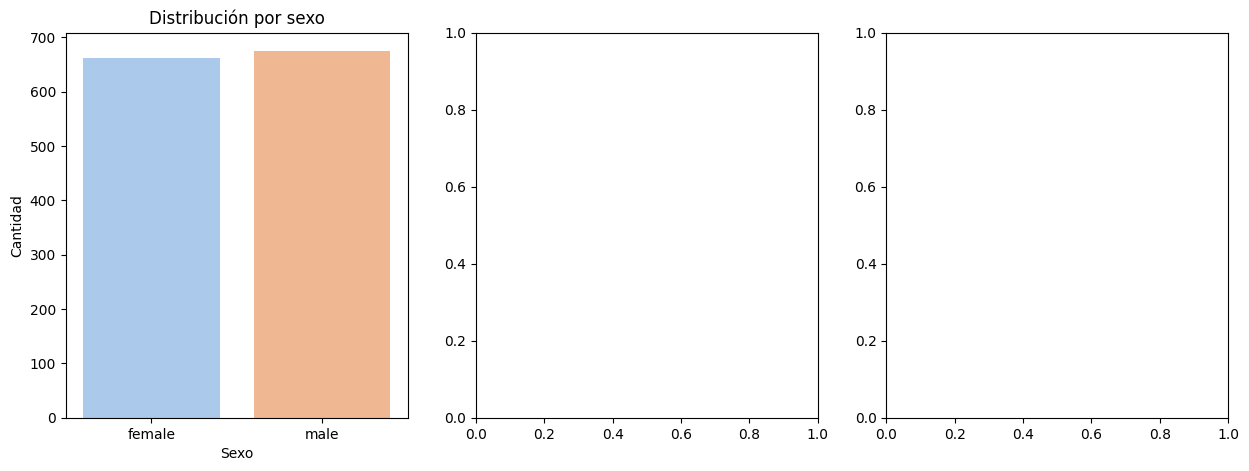

In [35]:
#VARIABLES CATEGÓRICAS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')
axes[0].set_title('Distribución por sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Cantidad')
print("Distribución sex:\n", df['sex'].value_counts())

In [36]:
sns.countplot(data=df, x='smoker', ax=axes[1], palette='pastel')
axes[1].set_title('Distribución fumadores')
axes[1].set_xlabel('¿Fumador?')
axes[1].set_ylabel('Cantidad')

print("\nDistribución smoker:\n", df['smoker'].value_counts())


Distribución smoker:
 smoker
no     1063
yes     274
Name: count, dtype: int64


/tmp/ipykernel_26191/960381394.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='smoker', ax=axes[1], palette='pastel')


In [37]:
sns.countplot(data=df, x='region', ax=axes[2], palette='pastel')
axes[2].set_title('Distribución por región')
axes[2].set_xlabel('Región')
axes[2].set_ylabel('Cantidad')
axes[2].tick_params(axis='x', rotation=15)
print("\nDistribución region:\n", df['region'].value_counts())
plt.tight_layout()
plt.show()


Distribución region:
 region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


/tmp/ipykernel_26191/1288375959.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', ax=axes[2], palette='pastel')


<Figure size 640x480 with 0 Axes>

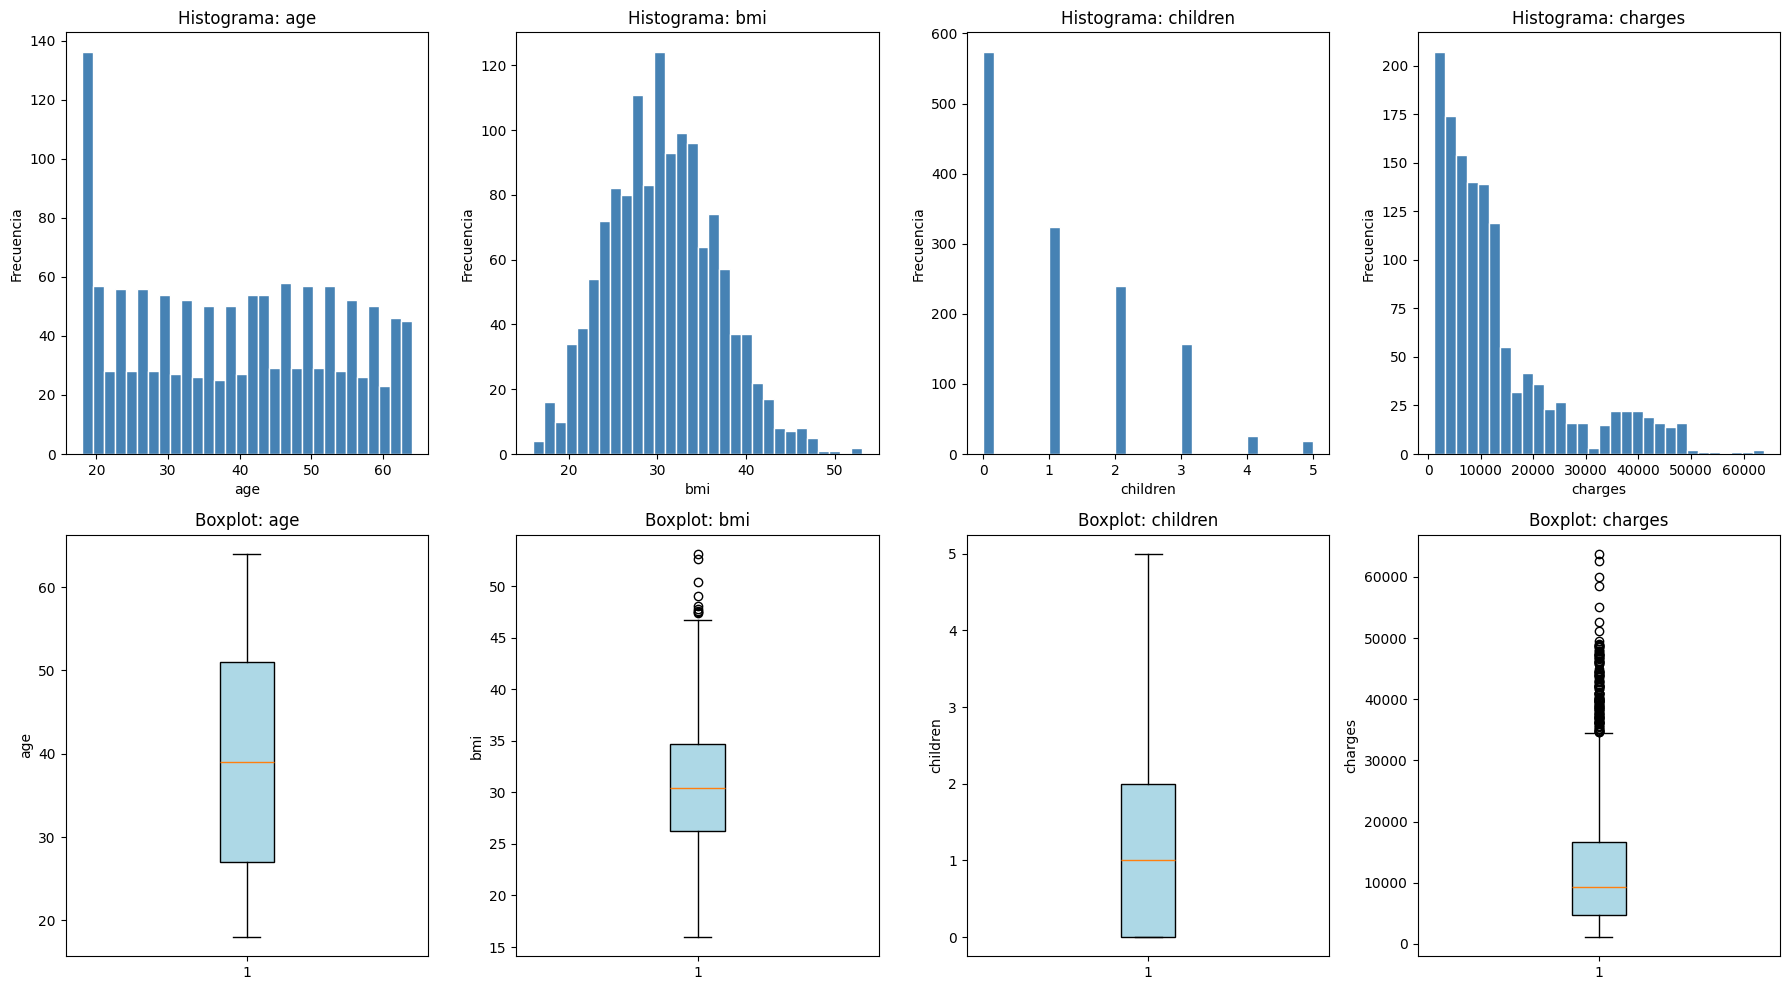

In [38]:
#VARIABLES NUMÉRICAS
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')   
    axes[0, i].set_title(f'Histograma: {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frecuencia')

    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))

    axes[1, i].set_title(f'Boxplot: {col}')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [39]:
for col in num_cols:
    print(f"\n{'='*40}")
    print(f"Variable: {col}")
    print(f"  Media:    {df[col].mean():.2f}")
   
    print(f"  Mediana:  {df[col].median():.2f}")

    print(f"  Std:      {df[col].std():.2f}")

    print(f"  Mín:      {df[col].min():.2f}")
    print(f"  Máx:      {df[col].max():.2f}")

    skew = df[col].skew()
    print(f"  Skewness: {skew:.2f}")


Variable: age
  Media:    39.22
  Mediana:  39.00
  Std:      14.04
  Mín:      18.00
  Máx:      64.00
  Skewness: 0.05

Variable: bmi
  Media:    30.66
  Mediana:  30.40
  Std:      6.10
  Mín:      15.96
  Máx:      53.13
  Skewness: 0.28

Variable: children
  Media:    1.10
  Mediana:  1.00
  Std:      1.21
  Mín:      0.00
  Máx:      5.00
  Skewness: 0.94

Variable: charges
  Media:    13279.12
  Mediana:  9386.16
  Std:      12110.36
  Mín:      1121.87
  Máx:      63770.43
  Skewness: 1.52


ANÁLISIS DE VARIABLES MULTIVARIANTE

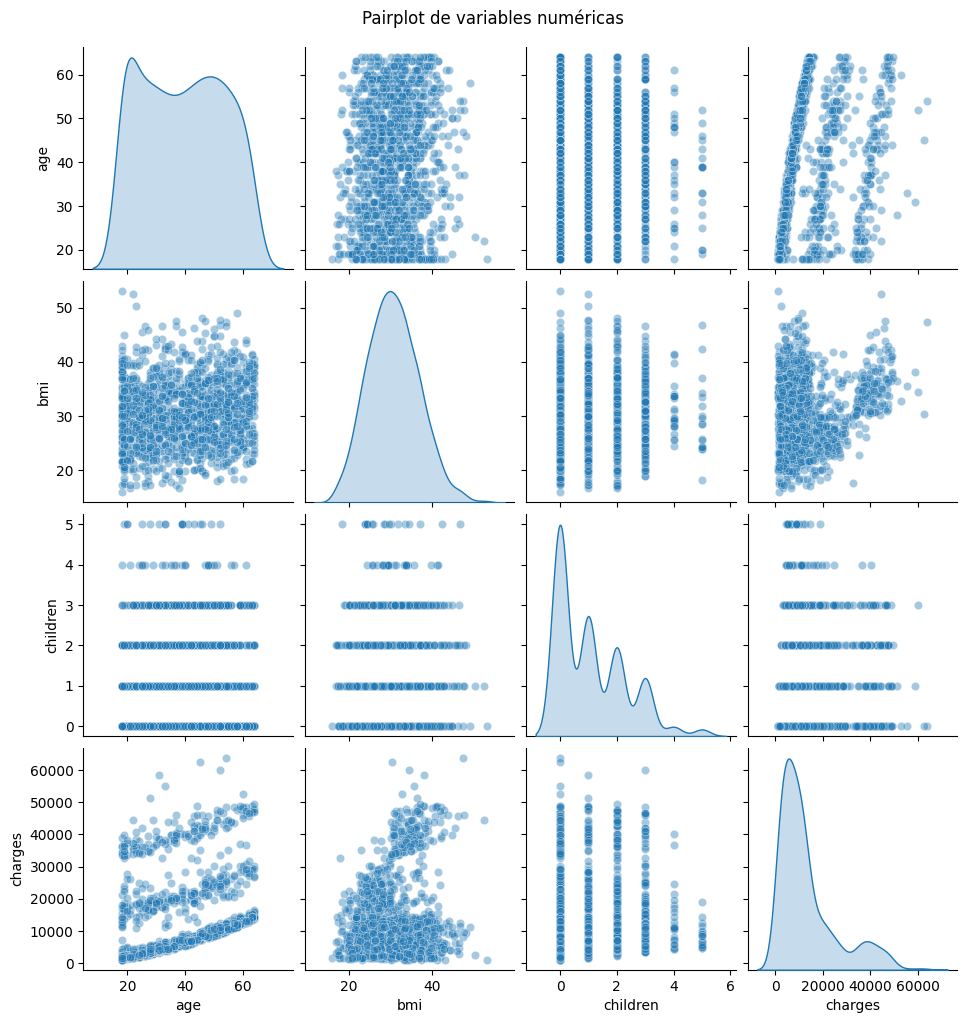

In [40]:
sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

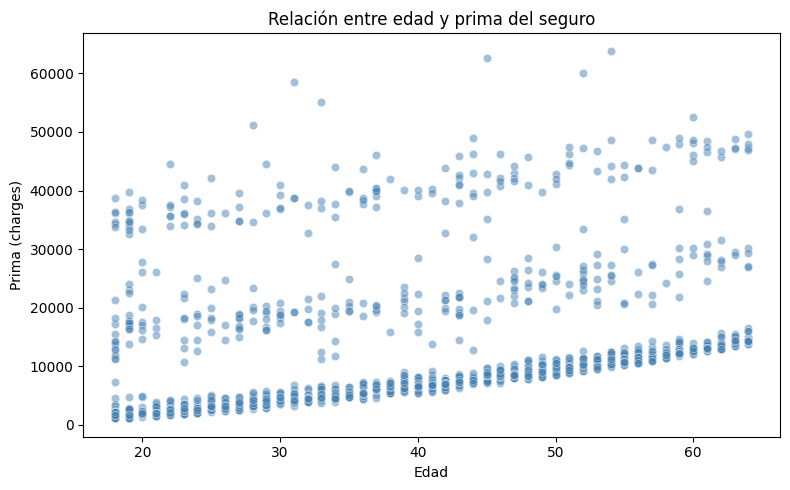

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', alpha=0.5, color='steelblue')

plt.title('Relación entre edad y prima del seguro')
plt.xlabel('Edad')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

ANÁLISIS CATEGÓRICO - CATEGÓRICO

Tabla cruzada sex vs smoker:
 smoker   no  yes
sex             
female  547  115
male    516  159


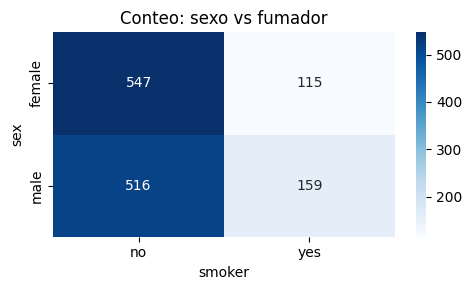

In [42]:
cross_sex_smoker = pd.crosstab(df['sex'], df['smoker'])
print("Tabla cruzada sex vs smoker:\n", cross_sex_smoker)

plt.figure(figsize=(5, 3))
sns.heatmap(cross_sex_smoker, annot=True, fmt='d', cmap='Blues')

plt.title('Conteo: sexo vs fumador')
plt.tight_layout()
plt.show()


Tabla cruzada region vs smoker:
 smoker      no  yes
region             
northeast  257   67
northwest  266   58
southeast  273   91
southwest  267   58


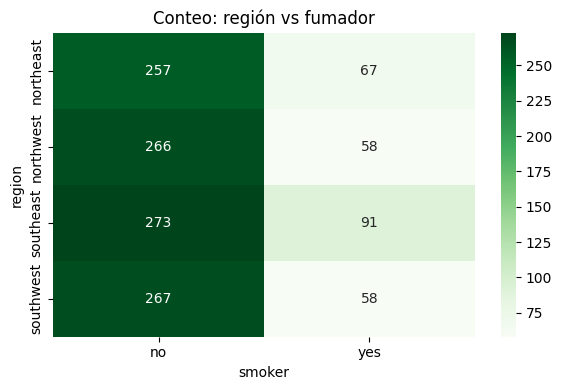

In [43]:
# region vs smoker
cross_region_smoker = pd.crosstab(df['region'], df['smoker'])
print("\nTabla cruzada region vs smoker:\n", cross_region_smoker)

plt.figure(figsize=(6, 4))
sns.heatmap(cross_region_smoker, annot=True, fmt='d', cmap='Greens')
plt.title('Conteo: región vs fumador')
plt.tight_layout()
plt.show()

/tmp/ipykernel_26191/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')
/tmp/ipykernel_26191/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')
/tmp/ipykernel_26191/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')


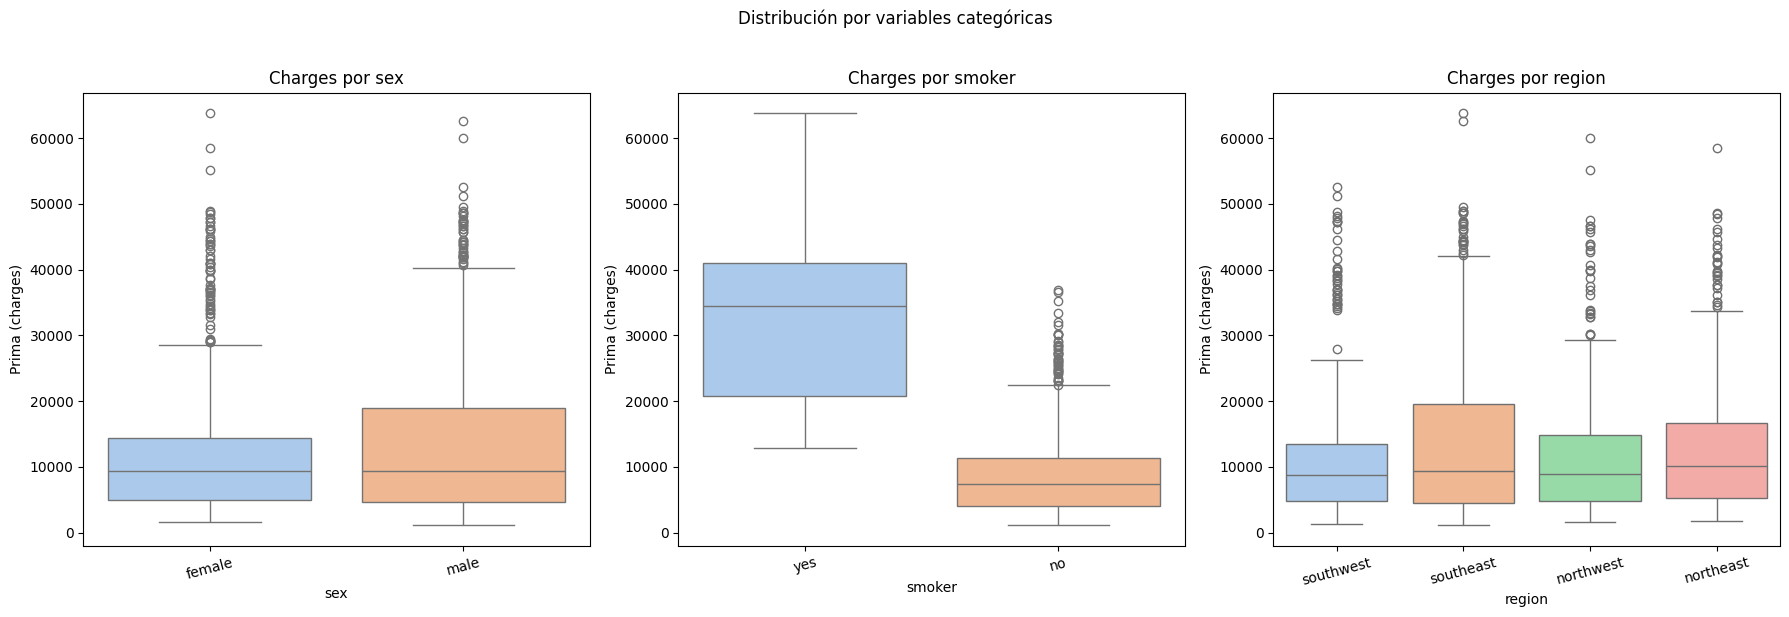

In [44]:
#COMBINACIONES DE LA CLASE (charges) CON VARIAS PREDICTORAS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cat_cols = ['sex', 'smoker', 'region']
# Lista de variables categóricas que compararemos contra charges
for i, col in enumerate(cat_cols):

    sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')

    axes[i].set_title(f'Charges por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Prima (charges)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Distribución por variables categóricas', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_26191/3365650621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='smoker', y='charges', palette='muted', inner='box')


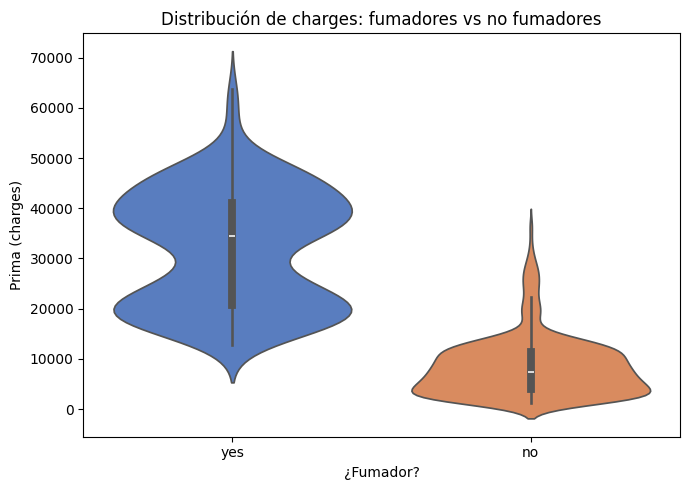

In [45]:
# smoker vs charges
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='smoker', y='charges', palette='muted', inner='box')

plt.title('Distribución de charges: fumadores vs no fumadores')
plt.xlabel('¿Fumador?')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

Qué observaremos: las primas de fumadores serán MUCHO más altas
Esta será probablemente la variable más importante del modelo

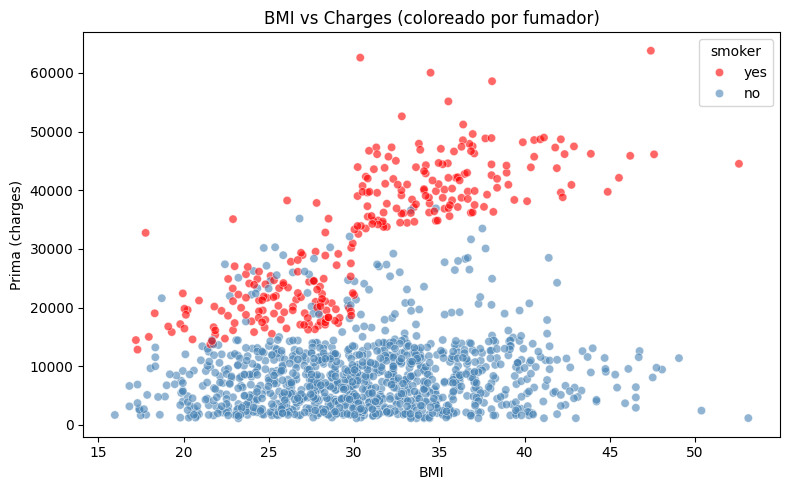

In [46]:
# ── Scatterplot: bmi vs charges, coloreado por smoker ────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes': 'red', 'no': 'steelblue'}, alpha=0.6)
# hue='smoker' → colorea cada punto según si es fumador o no
# palette      → rojo para fumadores, azul para no fumadores
# Esto nos permite ver 3 variables a la vez en un solo gráfico

plt.title('BMI vs Charges (coloreado por fumador)')
plt.xlabel('BMI')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

Qué observaremos: dos nubes de puntos bien separadas
Los fumadores con BMI alto tienen primas EXTREMADAMENTE altas
Hay una interacción entre bmi y smoker → puede ser útil crear una feature combinada

In [47]:
# ANÁLISIS DE CORRELACIONES 

df_encoded = df.copy()
# Hacemos una copia para no modificar el DataFrame original

df_encoded['sex']    = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
# map() reemplaza cada valor por el número que le asignamos
# male→1, female→0 | yes→1, no→0

df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
# get_dummies → convierte 'region' en columnas binarias (0 o 1)
# northwest → 1 si es northwest, 0 si no
# southeast → 1 si es southeast, 0 si no
# southwest → 1 si es southwest, 0 si no
# drop_first=True → elimina una categoría para evitar multicolinealidad
print(df_encoded.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


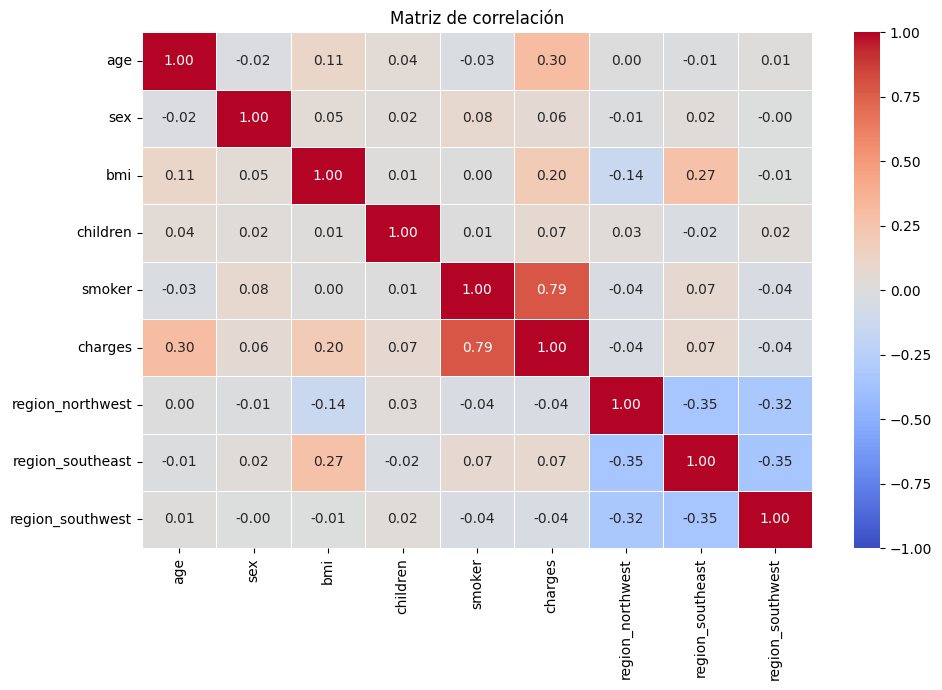

In [48]:
# Matriz de correlación 
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,        # escribe el valor numérico en cada celda
    fmt='.2f',         # 2 decimales
    cmap='coolwarm',   # azul=correlación negativa, rojo=positiva
    center=0,          # el blanco está en 0 (sin correlación)
    linewidths=0.5,    # líneas separadoras entre celdas
    vmin=-1, vmax=1    # fuerza la escala entre -1 y 1
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [49]:
print("\nCorrelación con 'charges' (de mayor a menor):")
print(corr_matrix['charges'].sort_values(ascending=False))


Correlación con 'charges' (de mayor a menor):
charges             1.000000
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64


In [50]:
# ── Conclusiones del EDA ──────────────────────────────────────
print("""
RESUMEN EDA - Conclusiones clave:
==================================
1. smoker es la variable MÁS importante → correlación ~0.79 con charges
2. age y bmi tienen correlación moderada con charges
3. children, sex y region tienen poca correlación con charges
4. La distribución de charges está muy sesgada (skewness alto)
5. Existe interacción entre bmi y smoker → posible feature engineering
6. No hay valores nulos ni duplicados relevantes → dataset limpio
""")


RESUMEN EDA - Conclusiones clave:
1. smoker es la variable MÁS importante → correlación ~0.79 con charges
2. age y bmi tienen correlación moderada con charges
3. children, sex y region tienen poca correlación con charges
4. La distribución de charges está muy sesgada (skewness alto)
5. Existe interacción entre bmi y smoker → posible feature engineering
6. No hay valores nulos ni duplicados relevantes → dataset limpio



Randon forest:

In [51]:
# X e y para regresión
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# División train/test (ya lo hiciste antes)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [52]:
# Crear variable objetivo
df_encoded['high_cost'] = (df_encoded['charges'] > df_encoded['charges'].median()).astype(int)

X_clf = df_encoded.drop(['charges', 'high_cost'], axis=1)
y_clf = df_encoded['high_cost']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)



In [53]:
#Regresión: 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_reg = RandomForestRegressor(
    n_estimators=200,      # número de árboles
    max_depth=None,        # profundidad máxima
    random_state=42
)

rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))


MAE: 2611.5262576654845
RMSE: 4664.783156478909
R2: 0.8815810405467632


Hiperparámetros clave:
Los dos más importantes
• 	n_estimators → número de árboles
• 	max_depth → profundidad máxima del bosque

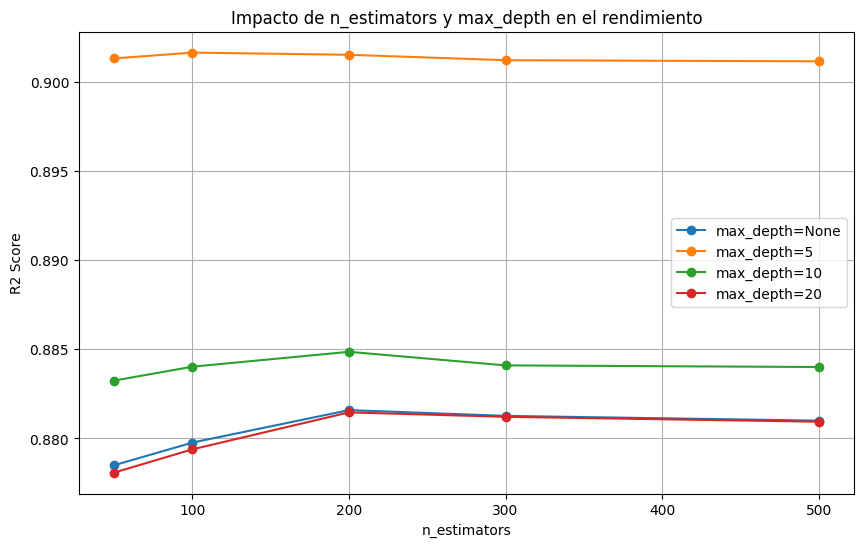

In [54]:
estimadores = [50, 100, 200, 300, 500]
profundidades = [None, 5, 10, 20]

resultados = {}

for n in estimadores:
    for d in profundidades:
        modelo = RandomForestRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=42
        )
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        r2 = r2_score(y_test, pred)
        resultados[(n, d)] = r2

# Graficar resultados
plt.figure(figsize=(10,6))
for d in profundidades:
    r2_vals = [resultados[(n, d)] for n in estimadores]
    plt.plot(estimadores, r2_vals, marker='o', label=f"max_depth={d}")

plt.xlabel("n_estimators")
plt.ylabel("R2 Score")
plt.title("Impacto de n_estimators y max_depth en el rendimiento")
plt.legend()
plt.grid(True)
plt.show()



In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [56]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = rf_clf.predict(X_test_clf)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print(confusion_matrix(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))



Accuracy: 0.9477611940298507
[[132   2]
 [ 12 122]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       134
           1       0.98      0.91      0.95       134

    accuracy                           0.95       268
   macro avg       0.95      0.95      0.95       268
weighted avg       0.95      0.95      0.95       268



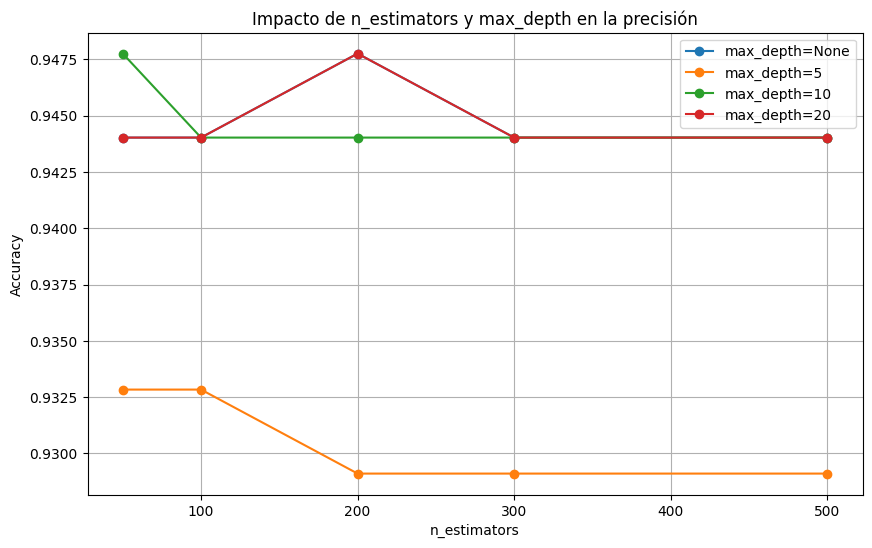

In [57]:
estimadores = [50, 100, 200, 300, 500]
profundidades = [None, 5, 10, 20]

resultados_clf = {}

for n in estimadores:
    for d in profundidades:
        modelo = RandomForestClassifier(
            n_estimators=n,
            max_depth=d,
            random_state=42
        )
        modelo.fit(X_train_clf, y_train_clf)
        pred = modelo.predict(X_test_clf)
        acc = accuracy_score(y_test_clf, pred)
        resultados_clf[(n, d)] = acc

plt.figure(figsize=(10,6))
for d in profundidades:
    acc_vals = [resultados_clf[(n, d)] for n in estimadores]
    plt.plot(estimadores, acc_vals, marker='o', label=f"max_depth={d}")

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Impacto de n_estimators y max_depth en la precisión")
plt.legend()
plt.grid(True)
plt.show()



In [59]:
import joblib
import os

os.makedirs("models", exist_ok=True)

In [60]:
joblib.dump(rf_reg, "models/random_forest_regression.pkl")
joblib.dump(rf_clf, "models/random_forest_classification.pkl")


['models/random_forest_classification.pkl']